# Urban Mobility vs Economic Productivity Analysis

## Objective
Analyze the relationship between urban mobility indicators (congestion, travel time) and economic productivity (GDP per capita).

## Tools Used
- Python
- Pandas
- Matplotlib / Seaborn
- Jupyter Notebook

In [2]:
# import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [10]:
# load datasets 
traffic = pd.read_csv('tomtom_traffic.csv')
eco = pd.read_csv('oecd_city_economy.csv')

In [11]:
# show the first 5 rows from traffic
traffic.head(5)

,Country,City,UpdateTimeUTC,JamsDelay,TrafficIndexLive,JamsLengthInKms,JamsCount,TrafficIndexWeekAgo,UpdateTimeUTCWeekAgo,TravelTimeLivePer10KmsMins,TravelTimeHistoricPer10KmsMins,MinsDelay
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232
3,ARE,abu-dhabi,2025-01-13 01:46:30.001,8.2,2.0,4.1,2.0,2.0,2025-01-06 01:46:30.000,7.723808,7.899046,-0.175238
4,ARE,abu-dhabi,2025-01-13 00:01:30.000,1.1,1.0,0.2,1.0,1.0,2025-01-06 00:01:30.000,8.336363,8.604379,-0.268016


### Dataset Structure Overview

We inspect the datasets to understand their structure, data types, and presence of missing values before proceeding with cleaning and analysis.

In [13]:
traffic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   Country                         1004464 non-null  object 
 1   City                            1004464 non-null  object 
 2   UpdateTimeUTC                   1004464 non-null  object 
 3   JamsDelay                       1004464 non-null  float64
 4   TrafficIndexLive                1004464 non-null  float64
 5   JamsLengthInKms                 1004464 non-null  float64
 6   JamsCount                       1004464 non-null  float64
 7   TrafficIndexWeekAgo             1004464 non-null  float64
 8   UpdateTimeUTCWeekAgo            1004464 non-null  object 
 9   TravelTimeLivePer10KmsMins      1004464 non-null  float64
 10  TravelTimeHistoricPer10KmsMins  1004464 non-null  float64
 11  MinsDelay                       1004464 non-null  float64
dtype

Now we inspect the next database: 

In [14]:
eco.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Year             30 non-null     int64 
 1   City             30 non-null     object
 2   Country          30 non-null     object
 3   City GDP/capita  30 non-null     object
 4   Unemployment %   30 non-null     object
 5   PM2.5 (μg/m³)    30 non-null     object
 6   Population (M)   30 non-null     object
dtypes: int64(1), object(6)
memory usage: 1.8+ KB


**Observation:** Both datasets show no missing values. However, several variables are incorrectly stored as objects, including date-related fields, unemployment percentage, and GDP per capita. These will be converted to appropriate numeric and datetime formats during data cleaning.

## Data Cleaning and Preparation

### Column Name Standardization (Traffic Dataset)

To ensure consistency and improve usability, column names in the traffic and eco datasets are standardized to lowercase snake_case format.

In [18]:
traffic = traffic.rename(columns={
    "Country": "country",
    "City": "city",
    "UpdateTimeUTC": "update_time_utc",
    "JamsDelay": "jams_delay",
    "TrafficIndexLive": "traffic_index_live",
    "JamsLengthInKms": "jams_length_in_kms",
    "JamsCount": "jams_count",
    "TrafficIndexWeekAgo": "traffic_index_week_ago",
    "UpdateTimeUTCWeekAgo": "update_time_utc_week_ago",
    "TravelTimeLivePer10KmsMins": "travel_time_live_per_10_kms_mins",
    "TravelTimeHistoricPer10KmsMins": "travel_time_hist_per_10_kms_mins",
    "MinsDelay": "mins_delay"
})

# verify
traffic.columns

Index(['country', 'city', 'update_time_utc', 'jams_delay',
       'traffic_index_live', 'jams_length_in_kms', 'jams_count',
       'traffic_index_week_ago', 'update_time_utc_week_ago',
       'travel_time_live_per_10_kms_mins', 'travel_time_hist_per_10_kms_mins',
       'mins_delay'],
      dtype='object')

### Column Name Standardization (Economic Dataset)

In [19]:
eco.columns = eco.columns.str.lower().str.replace('/', '_').str.replace('(', '').str.replace(')', '')

# verify
eco.columns

Index(['year', 'city', 'country', 'city gdp_capita', 'unemployment %',
       'pm2.5 μg_m³', 'population m'],
      dtype='object')

In [20]:
eco = eco.rename(columns={
    "city gdp_capita": "city_gdp_capita", 
    "unemployment %": "unemployment_pct", 
    "pm2.5 μg_m³": "pm25",
    "population m": "population_m",
})
eco.columns

Index(['year', 'city', 'country', 'city_gdp_capita', 'unemployment_pct',
       'pm25', 'population_m'],
      dtype='object')

**Result:** Column names have been successfully standardized, improving consistency for downstream analysis and merging operations.

### Datetime Conversion (Traffic Dataset)

Date-related columns are converted to datetime format to enable proper time-based analysis and ensure correct data types.

In [23]:
# Convert date columns to datetime
traffic['update_time_utc'] = pd.to_datetime(traffic['update_time_utc'], errors='coerce')
traffic['update_time_utc_week_ago'] = pd.to_datetime(traffic['update_time_utc_week_ago'], errors='coerce')

# Verify conversion
traffic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                            Non-Null Count    Dtype         
---  ------                            --------------    -----         
 0   country                           1004464 non-null  object        
 1   city                              1004464 non-null  object        
 2   update_time_utc                   1004464 non-null  datetime64[ns]
 3   jams_delay                        1004464 non-null  float64       
 4   traffic_index_live                1004464 non-null  float64       
 5   jams_length_in_kms                1004464 non-null  float64       
 6   jams_count                        1004464 non-null  float64       
 7   traffic_index_week_ago            1004464 non-null  float64       
 8   update_time_utc_week_ago          1004464 non-null  datetime64[ns]
 9   travel_time_live_per_10_kms_mins  1004464 non-null  float64       
 10  travel_time_hist_p

**Result:** Date columns were successfully converted to datetime format. Any invalid entries were safely coerced to null values for further review.

### Numeric Formatting and Conversion (Economic Dataset)

Several economic variables contain formatting inconsistencies (e.g., thousand separators, percentage symbols, and locale-specific decimals). These fields are cleaned and converted to numeric types to ensure accurate quantitative analysis.

In [24]:
# Clean separators and convert numeric columns
eco['city_gdp_capita'] = (
    eco['city_gdp_capita']
    .astype(str)
    .str.replace('.', '', regex=False)
    .str.replace(',', '.', regex=False)
    .astype(float)
)

eco['unemployment_pct'] = (
    eco['unemployment_pct']
    .astype(str)
    .str.replace('%', '', regex=False)
    .str.replace(',', '.', regex=False)
    .astype(float)
)

eco['population_m'] = (
    eco['population_m']
    .astype(str)
    .str.replace(',', '.', regex=False)
    .astype(float)
)

# Calculate absolute population
eco['population'] = eco['population_m'] * 1_000_000

# Verify results
eco.info()
eco.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   year              30 non-null     int64  
 1   city              30 non-null     object 
 2   country           30 non-null     object 
 3   city_gdp_capita   30 non-null     float64
 4   unemployment_pct  30 non-null     float64
 5   pm25              30 non-null     object 
 6   population_m      30 non-null     float64
 7   population        30 non-null     float64
dtypes: float64(4), int64(1), object(3)
memory usage: 2.0+ KB


,year,city,country,city_gdp_capita,unemployment_pct,pm25,population_m,population
0,2023,buenos-aires,Argentina,15782.0,6.2,"15,2",15.3,15300000.0
1,2023,sao-paulo,Brazil,14475.0,9.1,"29,50",22.5,22500000.0
2,2023,rio-de-janeiro,Brazil,13142.0,9.8,"19,10",13.6,13600000.0


**Result:** Economic indicators were successfully converted to numeric format. Population was derived in absolute terms to support cross-city comparisons and aggregation.

### Year Extraction and Filtering

To focus the analysis on the most recent and relevant period, the year is extracted from the traffic timestamp. Both datasets are then filtered to retain only 2024 records, creating dedicated working subsets while preserving the original data.

In [25]:
# Extract year from traffic timestamp
traffic['year'] = traffic['update_time_utc'].dt.year

# Filter datasets for 2024 and create working copies
traffic_2024 = traffic[traffic['year'] == 2024].copy()
eco_2024 = eco[eco['year'] == 2024].copy()

# Quick verification
display(traffic_2024.head())
display(eco_2024.head())

,country,city,update_time_utc,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,traffic_index_week_ago,update_time_utc_week_ago,travel_time_live_per_10_kms_mins,travel_time_hist_per_10_kms_mins,mins_delay,year
302,ARE,abu-dhabi,2024-12-31 23:01:30.000,12.9,5.0,2.5,5.0,2.0,2024-12-24 23:01:30.001,8.560399,8.519634,0.040765,2024
303,ARE,abu-dhabi,2024-12-31 22:01:30.000,136.0,21.0,20.6,32.0,3.0,2024-12-24 22:01:30.000,10.355732,9.049445,1.306286,2024
304,ARE,abu-dhabi,2024-12-31 21:16:30.000,455.2,31.0,40.4,72.0,4.0,2024-12-24 21:01:30.000,11.456878,9.305174,2.151704,2024
305,ARE,abu-dhabi,2024-12-31 20:01:00.001,399.4,27.0,38.0,75.0,6.0,2024-12-24 20:01:30.001,11.670062,9.952811,1.717252,2024
306,ARE,abu-dhabi,2024-12-31 19:46:00.000,366.4,28.0,39.8,82.0,9.0,2024-12-24 19:01:00.000,11.686322,10.008469,1.677853,2024


,year,city,country,city_gdp_capita,unemployment_pct,pm25,population_m,population
15,2024,buenos-aires,Argentina,18117.0,7.2,"14,50",15.4,15400000.0
16,2024,sao-paulo,Brazil,14703.0,8.5,"28,00",22.6,22600000.0
17,2024,rio-de-janeiro,Brazil,13349.0,9.2,"18,40",13.7,13700000.0
18,2024,brasilia,Brazil,16251.0,7.8,"12,80",4.8,4800000.0
19,2024,salvador,Brazil,8899.0,12.4,"15,20",3.9,3900000.0


### Traffic Aggregation by City (2024)

Traffic data contains multiple records per city. To support city-level analysis, key mobility indicators are aggregated by city, country, and year using the mean.

In [26]:
# Add average traffic metrics by city, country, and year
traffic_city_year_2024 = (
    traffic_2024
    .groupby(["city", "country", "year"])[[
        "jams_delay",
        "traffic_index_live",
        "jams_length_in_kms",
        "jams_count",
        "mins_delay",
        "travel_time_live_per_10_kms_mins",
        "travel_time_hist_per_10_kms_mins"
    ]]
    .mean()
    .reset_index()
)

# Verify results
traffic_city_year_2024.head()

,city,country,year,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,mins_delay,travel_time_live_per_10_kms_mins,travel_time_hist_per_10_kms_mins
0,a-coruna,ESP,2024,17.935187,15.259774,2.198002,4.934405,0.774172,16.267977,15.493804
1,aachen,DEU,2024,26.732141,20.960314,3.892586,6.601832,0.792968,13.397861,12.604894
2,aarhus,DNK,2024,21.200616,16.575891,2.736736,6.109987,0.495276,15.219292,14.724016
3,abu-dhabi,ARE,2024,171.157315,13.902028,24.507380,47.268019,0.139764,9.829092,9.689328
4,adana,TUR,2024,83.864761,22.541040,11.827331,23.754620,1.129749,15.879694,14.749945


### Identifying Cities with Highest Congestion

To understand the distribution of traffic burden across cities, the dataset is sorted by average delay. This helps identify the most congested urban areas in 2024 and provides context for later comparisons with economic indicators.

In [27]:
traffic_city_year_2024.sort_values(["jams_delay"], ascending=False)

,city,country,year,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,mins_delay,travel_time_live_per_10_kms_mins,travel_time_hist_per_10_kms_mins
221,mexico-city,MEX,2024,2833.057892,34.218190,389.239265,594.969392,1.855542,21.809092,19.953550
352,tokyo,JPN,2024,2152.574357,36.805059,373.069734,518.809420,0.698152,22.443778,21.745626
246,new-york,USA,2024,2133.400000,28.210388,398.227892,544.474902,1.396351,18.505043,17.108691
200,london,GBR,2024,2050.703662,29.230166,287.632868,471.795554,1.325160,17.714139,16.388979
211,manila,PHL,2024,1741.493381,66.129402,246.858082,341.881205,2.469894,27.134629,24.664734
...,...,...,...,...,...,...,...,...,...,...
111,dunedin,NZL,2024,4.651175,15.430809,0.712315,1.591384,0.633294,16.226009,15.592715
363,uppsala,SWE,2024,4.194486,13.939168,0.656368,1.349672,0.501802,15.746717,15.244916
123,fujairah,ARE,2024,4.025959,10.907719,0.731910,1.373006,0.194951,11.662590,11.467639
12,almere,NLD,2024,3.633523,6.290478,0.506362,1.064063,-0.017544,9.467150,9.484694


**Result:** The ranking highlights the cities experiencing the highest average traffic delay in 2024, revealing potential urban mobility pressure points for further analysis.

### Dataset Preparation and Integration

Relevant mobility and economic indicators were selected and merged into a unified analytical dataset. This step enables direct comparison between urban traffic conditions and economic productivity at the city level.

In [28]:
# Select key traffic and economic columns
left_cols = [
    'city', 'country', 'year', 'jams_delay', 'traffic_index_live',
    'jams_length_in_kms', 'jams_count', 'mins_delay',
    'travel_time_live_per_10_kms_mins', 'travel_time_hist_per_10_kms_mins'
]

right_cols = [
    'city', 'country', 'year',
    'city_gdp_capita', 'unemployment_pct', 'pm25', 'population_m'
]

# Create reduced datasets
traffic_2024_small = traffic_city_year_2024[left_cols].copy()
eco_2024_small = eco_2024[right_cols].copy()

# Merge datasets
merged_data = pd.merge(
    traffic_2024_small,
    eco_2024_small,
    on=['city', 'year'],
    how='inner'
)

# Preview merged data
merged_data.head(5)

,city,country_x,year,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,mins_delay,travel_time_live_per_10_kms_mins,travel_time_hist_per_10_kms_mins,country_y,city_gdp_capita,unemployment_pct,pm25,population_m
0,belo-horizonte,BRA,2024,263.047879,19.428946,44.038129,68.805422,0.487228,18.304538,17.817311,Brazil,11124.0,9.5,"16,80",6.1
1,bogota,COL,2024,1141.552364,37.614273,140.893564,230.566550,1.699628,24.992185,23.292557,Colombia,11442.0,10.0,"17,60",11.3
2,brasilia,BRA,2024,101.576326,11.258220,18.337133,27.280140,0.193442,13.338658,13.145216,Brazil,16251.0,7.8,"12,80",4.8
3,buenos-aires,ARG,2024,571.089593,17.756012,100.287844,137.359860,0.416566,17.907916,17.491349,Argentina,18117.0,7.2,"14,50",15.4
4,curitiba,BRA,2024,183.469274,14.954545,30.050044,46.898164,0.139965,17.258700,17.118736,Brazil,12381.0,8.2,"13,50",3.7


## Exploratory Analysis: Mobility vs Economic Indicators

### Distribution of Traffic Congestion (Jams Delay)
A boxplot was generated to examine the distribution and central tendency of congestion delay across cities in 2024.

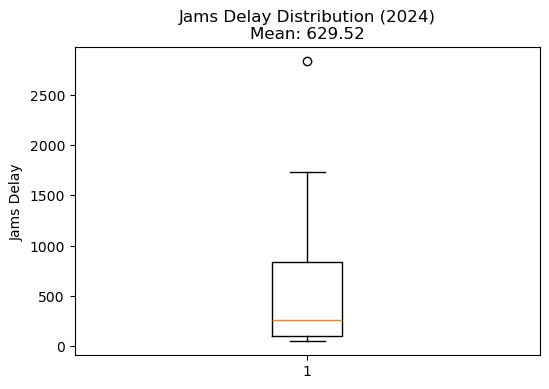

In [37]:
# Boxplot to examine distribution of congestion delay (JamsDelay)

plt.figure(figsize=(6,4))
plt.boxplot(merged_data['jams_delay'])

mean_value = merged_data['jams_delay'].mean()
plt.title(f'Jams Delay Distribution (2024)\nMean: {mean_value:.2f}')

plt.ylabel('Jams Delay')
plt.savefig("p01_jams_delay_boxplot.png", dpi=300, bbox_inches="tight")
plt.show()

**Result:** The distribution of congestion delay shows variability across cities, with the mean providing a reference point for typical traffic conditions in 2024.

### Distribution of Economic Productivity (GDP per Capita)

A histogram was generated to examine the distribution of GDP per capita across cities in 2024.

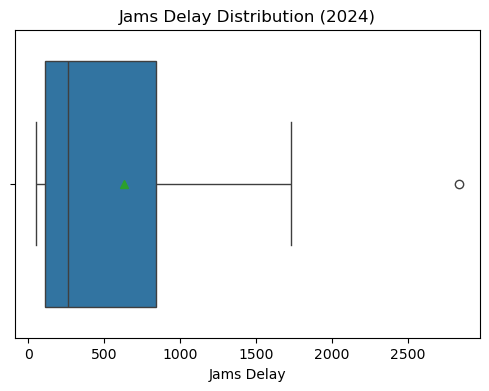

In [38]:
# Histogram to examine distribution of city GDP per capita

import seaborn as sns
import matplotlib.pyplot as plt


plt.figure(figsize=(6,4))

sns.boxplot(x=merged_data["jams_delay"], showmeans=True)
plt.title("Jams Delay Distribution (2024)")
plt.xlabel("Jams Delay")
plt.savefig("p01_jams_delay_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

**Result:** GDP per capita shows dispersion across cities, suggesting heterogeneous economic productivity levels in the sample.

### Traffic vs Economic Productivity by City

A comparative bar chart was created to examine how average congestion delay relates to GDP per capita across cities in 2024.

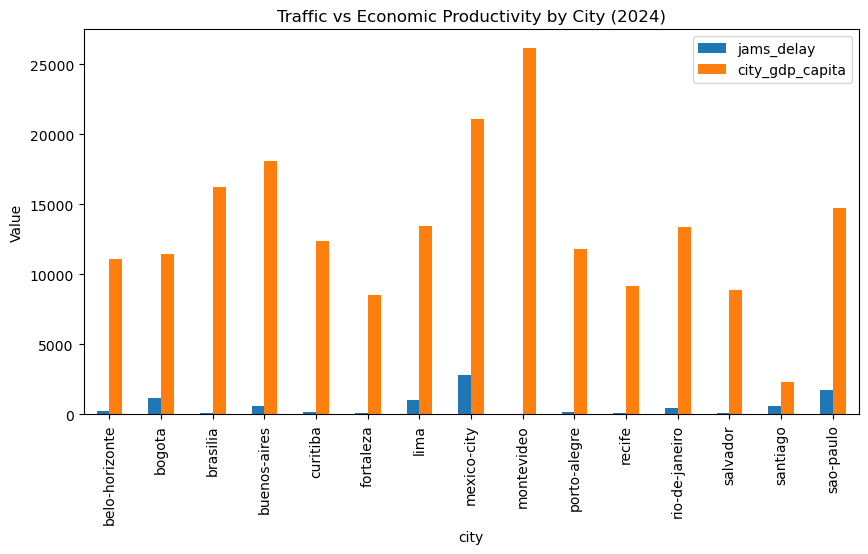

In [35]:
# Bar chart comparing congestion delay and GDP per capita by city

merged_data.plot(
    x="city",
    y=["jams_delay", "city_gdp_capita"],
    kind="bar",
    figsize=(10,5)
)

plt.title("Traffic vs Economic Productivity by City (2024)")
plt.xticks(rotation=90)
plt.ylabel("Value")
plt.savefig("p01_traffic_vs_economy.png", dpi=300, bbox_inches="tight")
plt.show()

**Result:** The comparison reveals notable variation between congestion levels and economic output across cities, suggesting the relationship may not be strictly linear and warrants further analysis.

In [39]:
merged_data[['jams_delay','city_gdp_capita','traffic_index_live']].corr()

,jams_delay,city_gdp_capita,traffic_index_live
jams_delay,1.000000,0.282975,0.765017
city_gdp_capita,0.282975,1.000000,0.056001
traffic_index_live,0.765017,0.056001,1.000000
